# Momentum Engineering (Notebook)

This notebook mirrors `momentum.py` and adds visual checks at each step.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
BASE_DIR = Path(".")
valid_bookings_df = pd.read_parquet(BASE_DIR / "valid_bookings.parquet")
valid_bookings_df.head()

,has_shopee_pay,has_special_request,medium,refund,end_time,start_time,id,is_temporary,for_locking_system,no_show,...,ack,adjusted,active,prepared,revenue_dollars,booking_date,day_of_week_index,day_of_week,is_outlier,outlier_reason
0,0.0,0.0,iOS,<NA>,17:00:00,15:00:00,865732,False,False,False,...,True,False,True,True,553.00,2025-12-01,0,Monday,False,
1,0.0,0.0,Web,False,18:00:00,16:00:00,2137851,False,False,False,...,True,False,False,False,79.20,2024-10-31,3,Thursday,False,
2,0.0,1.0,Web,False,20:00:00,18:00:00,2137857,False,False,False,...,True,False,False,False,79.20,2024-10-31,3,Thursday,False,
3,NaN,NaN,<NA>,False,19:00:00,19:00:00,3391224,False,False,False,...,True,False,True,False,149.93,2025-05-13,1,Tuesday,False,
4,0.0,0.0,Web,False,19:00:00,19:00:00,3440352,False,False,False,...,True,False,True,False,302.25,2024-06-17,0,Monday,False,


In [2]:
#remove outliers from restaurant_id based on google sheet 
outlier_ids = [4503, 4502, 933, 837]
valid_bookings_df = valid_bookings_df[~valid_bookings_df['restaurant_id'].isin(outlier_ids)]
valid_bookings_df.shape


(2378953, 27)

In [4]:
BASE_PATH = Path.cwd().parent.parent
PARQUET_PATH = BASE_PATH / "data" / "mv_dataset_parquet"
restaurants = pd.read_parquet(PARQUET_PATH / "restaurants.parquet")
restaurants.shape

(2474, 3)

In [5]:
valid_bookings_df.shape

(2378953, 27)

In [6]:
valid_bookings_df = valid_bookings_df.merge(restaurants, on="restaurant_id", how="left")
valid_bookings_df.head()

,has_shopee_pay,has_special_request,medium,refund,end_time,start_time,id,is_temporary,for_locking_system,no_show,...,active,prepared,revenue_dollars,booking_date,day_of_week_index,day_of_week,is_outlier,outlier_reason,name,days_in_advance
0,0.0,0.0,iOS,<NA>,17:00:00,15:00:00,865732,False,False,False,...,True,True,553.0,2025-12-01,0,Monday,False,,The Coffee Club Tha Maharaj,90.0
1,0.0,0.0,Web,False,18:00:00,16:00:00,2137851,False,False,False,...,False,False,79.2,2024-10-31,3,Thursday,False,,<NA>,NaN
2,0.0,1.0,Web,False,20:00:00,18:00:00,2137857,False,False,False,...,False,False,79.2,2024-10-31,3,Thursday,False,,<NA>,NaN
3,0.0,1.0,Vendor_App,False,17:00:00,15:00:00,3448943,False,False,True,...,True,False,114.4,2025-04-01,1,Tuesday,False,,Audrey Cafe Thonglor Soi 11,90.0
4,0.0,1.0,Vendor_App,False,17:00:00,15:00:00,3448944,False,False,True,...,True,False,114.4,2025-04-01,1,Tuesday,False,,Audrey Cafe Thonglor Soi 11,90.0


In [7]:
#retrieve places api data from csv
CSV_PATH = BASE_PATH / "_1_eda" / "places_api_new_results.csv"

# Load the CSV
google_restaurants_df = pd.read_csv(CSV_PATH)
google_restaurants_df.shape

(2392, 12)

In [8]:
valid_bookings_df = valid_bookings_df.merge(google_restaurants_df, left_on='name', right_on='input_string', how='left')
valid_bookings_df.head()

,has_shopee_pay,has_special_request,medium,refund,end_time,start_time,id,is_temporary,for_locking_system,no_show,...,official_name,city,country,formatted_address,rating,website,error,Cuisine,Cuisine_confidence,raw_types
0,0.0,0.0,iOS,<NA>,17:00:00,15:00:00,865732,False,False,False,...,THE COFFEE CLUB - Tha Maharaj,NaN,Thailand,"1/11 at Mahathat Alley, Tha, ถ. มหาราช แขวงพระ...",4.6,https://thecoffeeclub.co.th/,API key not valid. Please pass a valid API key.,Cafe,0.85,"coffee_shop,cafe,food_store,food,store,point_o..."
1,0.0,0.0,Web,False,18:00:00,16:00:00,2137851,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,1.0,Web,False,20:00:00,18:00:00,2137857,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,1.0,Vendor_App,False,17:00:00,15:00:00,3448943,False,False,True,...,AUDREY CAFE & BISTRO,NaN,Thailand,"Soi Thong Lo 11, Khwaeng Khlong Tan Nuea, Watt...",4.2,http://www.audreygroup.com/,API key not valid. Please pass a valid API key.,Cafe,0.60,"restaurant,wedding_venue,event_venue,cafe,poin..."
4,0.0,1.0,Vendor_App,False,17:00:00,15:00:00,3448944,False,False,True,...,AUDREY CAFE & BISTRO,NaN,Thailand,"Soi Thong Lo 11, Khwaeng Khlong Tan Nuea, Watt...",4.2,http://www.audreygroup.com/,API key not valid. Please pass a valid API key.,Cafe,0.60,"restaurant,wedding_venue,event_venue,cafe,poin..."


In [11]:
valid_bookings_df.columns

Index(['has_shopee_pay', 'has_special_request', 'medium', 'refund', 'end_time',
       'start_time', 'id', 'is_temporary', 'for_locking_system', 'no_show',
       'arrived', 'channel', 'user_id_masked', 'adult', 'kids',
       'restaurant_id', 'created_at', 'ack', 'adjusted', 'active', 'prepared',
       'revenue_dollars', 'booking_date', 'day_of_week_index', 'day_of_week',
       'is_outlier', 'outlier_reason', 'name', 'days_in_advance',
       'input_string', 'found', 'official_name', 'city', 'country',
       'formatted_address', 'rating', 'website', 'error', 'Cuisine',
       'Cuisine_confidence', 'raw_types'],
      dtype='object')

In [13]:
import requests

# 1. Setup Currency Reference
country_to_currency = {
    'Thailand': 'THB', 'Singapore': 'SGD', 'Malaysia': 'MYR',
    'United States': 'USD', 'Japan': 'JPY', 'Hong Kong': 'HKD',
    'United Kingdom': 'GBP', 'Australia': 'AUD', 'Vietnam': 'VND',
    'Indonesia': 'IDR', 'India': 'INR', 'France': 'EUR',
    'Italy': 'EUR', 'Netherlands': 'EUR'
}

# 2. Fetch Live Rates
def get_live_rates(base_currency='USD'):
    url = f"https://open.er-api.com/v6/latest/{base_currency}"
    try:
        response = requests.get(url)
        data = response.json()
        if data['result'] == 'success':
            return data['rates']
    except Exception:
        pass
    # Fallback to approx rates if API is down
    return {'THB': 35.5, 'SGD': 1.34, 'MYR': 4.7, 'JPY': 150.0, 'USD': 1.0, 'EUR': 0.92}

exchange_rates = get_live_rates('USD')

# 3. Clean and Validate DataFrame
# Note: Ensure 'country' and 'revenue_dollars' exist for the conversion to work
required_cols = ["restaurant_id", "booking_date", "id", "revenue_dollars", "country"]
missing = [c for c in required_cols if c not in valid_bookings_df.columns]
if missing:
    raise ValueError(f"valid_bookings_df missing required columns: {missing}")

# Handle Dates and NaNs
valid_bookings_df["booking_date"] = pd.to_datetime(valid_bookings_df["booking_date"], errors="coerce")
valid_bookings_df = valid_bookings_df.dropna(subset=["booking_date", "restaurant_id"])

# 4. Apply Currency Conversion
def perform_conversion(row):
    country = row['country']
    amount = row['revenue_dollars']
    currency_code = country_to_currency.get(country)
    
    if currency_code and pd.notnull(amount):
        rate = exchange_rates.get(currency_code)
        if rate:
            # API gives 1 USD = X Local. So we divide Local / Rate to get USD.
            return amount / rate
    return amount

valid_bookings_df["revenue_usd"] = valid_bookings_df.apply(perform_conversion, axis=1)

# 5. Handle Guest Logic
if "total_guests" not in valid_bookings_df.columns:
    if "adult" in valid_bookings_df.columns and "kids" in valid_bookings_df.columns:
        valid_bookings_df["total_guests"] = (
            valid_bookings_df["adult"].fillna(0) + valid_bookings_df["kids"].fillna(0)
        )
    else:
        valid_bookings_df["total_guests"] = np.nan

print(f"Final Shape: {valid_bookings_df.shape}")

Final Shape: (2378953, 43)


## 0) Guardrails / required cols

In [ ]:
# required_cols = ["restaurant_id", "booking_date", "id", "revenue_dollars"]
# missing = [c for c in required_cols if c not in valid_bookings_df.columns]
# if missing:
#     raise ValueError(f"valid_bookings_df missing required columns: {missing}")

# valid_bookings_df["booking_date"] = pd.to_datetime(valid_bookings_df["booking_date"], errors="coerce")
# valid_bookings_df = valid_bookings_df.dropna(subset=["booking_date", "restaurant_id"])

# if "total_guests" not in valid_bookings_df.columns:
#     if "adult" in valid_bookings_df.columns and "kids" in valid_bookings_df.columns:
#         valid_bookings_df["total_guests"] = (
#             valid_bookings_df["adult"].fillna(0) + valid_bookings_df["kids"].fillna(0)
#         )
#     else:
#         valid_bookings_df["total_guests"] = np.nan

# valid_bookings_df.shape

(2378953, 28)

## 1) Monthly aggregation

In [ ]:
valid_bookings_df["year_month"] = valid_bookings_df["booking_date"].dt.to_period("M").dt.to_timestamp()

# Filter out advance bookings beyond Dec 2025
cutoff_month = pd.Timestamp("2025-12-01")
valid_bookings_df = valid_bookings_df[valid_bookings_df["year_month"] <= cutoff_month].copy()

restaurants_agg = (
    valid_bookings_df
    .groupby(["restaurant_id", "year_month"], as_index=False)
    .agg(
        monthly_bookings=("id", "count"),
        monthly_revenue=("revenue_usd", "sum"),
        avg_revenue_per_booking=("revenue_usd", "mean"),
        avg_guests=("total_guests", "mean"),
        active_days=("booking_date", lambda x: x.dt.date.nunique()),
    )
)

#do note monthly_revenue here refers to the usd denominated revenue, please confirm based on above steps 
restaurants_agg["monthly_bookings"] = restaurants_agg["monthly_bookings"].fillna(0).astype(int)
restaurants_agg["monthly_revenue"] = restaurants_agg["monthly_revenue"].fillna(0.0)
restaurants_agg["avg_revenue_per_booking"] = restaurants_agg["avg_revenue_per_booking"].replace([np.inf, -np.inf], np.nan)
restaurants_agg["avg_revenue_per_booking"] = restaurants_agg["avg_revenue_per_booking"].fillna(0.0)

restaurants_agg = restaurants_agg.sort_values(["restaurant_id", "year_month"]).reset_index(drop=True)
restaurants_agg.head()

,restaurant_id,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days
0,33,2024-01-01,155,1785.960605,11.522326,5.877419,13
1,33,2024-02-01,1360,5756.141787,4.232457,2.759559,27
2,33,2024-03-01,419,3377.031821,8.059742,4.119332,30
3,33,2024-04-01,649,3693.982442,5.691807,3.024653,29
4,33,2024-05-01,193,1375.831368,7.128660,3.797927,30


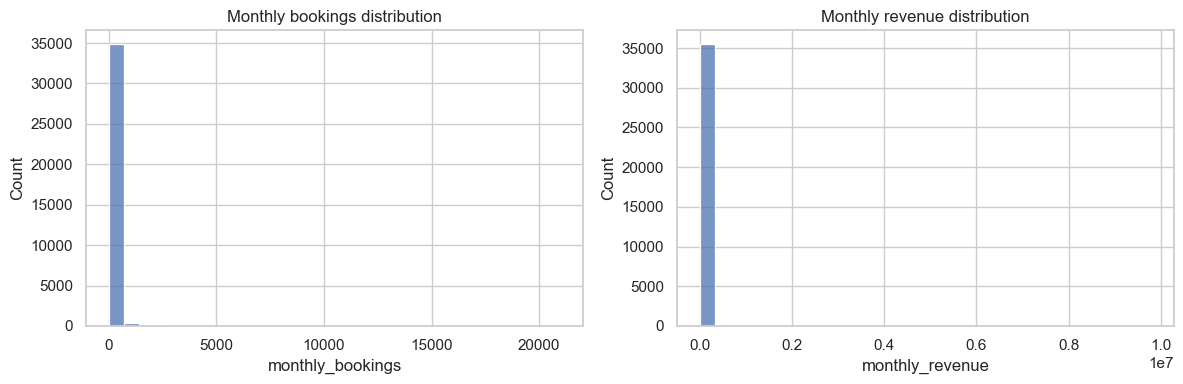

In [15]:
# Plot bookings and revenue distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(restaurants_agg["monthly_bookings"], bins=30, ax=axes[0])
axes[0].set_title("Monthly bookings distribution")

sns.histplot(restaurants_agg["monthly_revenue"], bins=30, ax=axes[1])
axes[1].set_title("Monthly revenue distribution")
plt.tight_layout()

## 2) Minimum history filter

In [16]:
MIN_MONTHS = 3
hist = restaurants_agg.groupby("restaurant_id")["year_month"].nunique()
keep_ids = hist[hist >= MIN_MONTHS].index
restaurants_agg = restaurants_agg[restaurants_agg["restaurant_id"].isin(keep_ids)].copy()
restaurants_agg.shape

(34490, 7)

## 3) Winsorise extremes

In [17]:
def winsorise_series(s: pd.Series, lower_q=0.01, upper_q=0.99) -> pd.Series:
    lo = s.quantile(lower_q)
    hi = s.quantile(upper_q)
    return s.clip(lower=lo, upper=hi)

for col in ["monthly_bookings", "monthly_revenue", "avg_revenue_per_booking"]:
    restaurants_agg[col] = winsorise_series(restaurants_agg[col])

restaurants_agg[["monthly_bookings","monthly_revenue","avg_revenue_per_booking"]].describe().T

,count,mean,std,min,25%,50%,75%,max
monthly_bookings,34490.0,53.578911,161.225447,1.000000,3.000000,8.000000,26.000000,1158.770000
monthly_revenue,34490.0,2752.776722,9763.257743,2.265007,30.055386,175.547487,1063.229720,75937.140000
avg_revenue_per_booking,34490.0,83.113465,142.160013,1.598048,5.171766,10.909784,119.676667,781.331133


## 4) Growth + rolling growth

In [18]:
restaurants_agg["booking_growth_pct"] = (
    restaurants_agg.groupby("restaurant_id")["monthly_bookings"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
)

restaurants_agg["revenue_growth_pct"] = (
    restaurants_agg.groupby("restaurant_id")["monthly_revenue"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
)

ROLL = 3
restaurants_agg["booking_growth_rolling"] = (
    restaurants_agg.groupby("restaurant_id")["booking_growth_pct"]
    .rolling(ROLL, min_periods=ROLL)
    .mean()
    .reset_index(level=0, drop=True)
)

restaurants_agg["revenue_growth_rolling"] = (
    restaurants_agg.groupby("restaurant_id")["revenue_growth_pct"]
    .rolling(ROLL, min_periods=ROLL)
    .mean()
    .reset_index(level=0, drop=True)
)

restaurants_agg["booking_growth_rolling"] = restaurants_agg["booking_growth_rolling"].fillna(0.0)
restaurants_agg["revenue_growth_rolling"] = restaurants_agg["revenue_growth_rolling"].fillna(0.0)

restaurants_agg[["booking_growth_rolling","revenue_growth_rolling"]].describe().T

,count,mean,std,min,25%,50%,75%,max
booking_growth_rolling,34490.0,1.395329,11.765708,-0.860131,0.0,0.055556,0.626043,388.199111
revenue_growth_rolling,34490.0,1.537521,15.430026,-0.853139,0.0,0.086017,0.759127,1787.822230


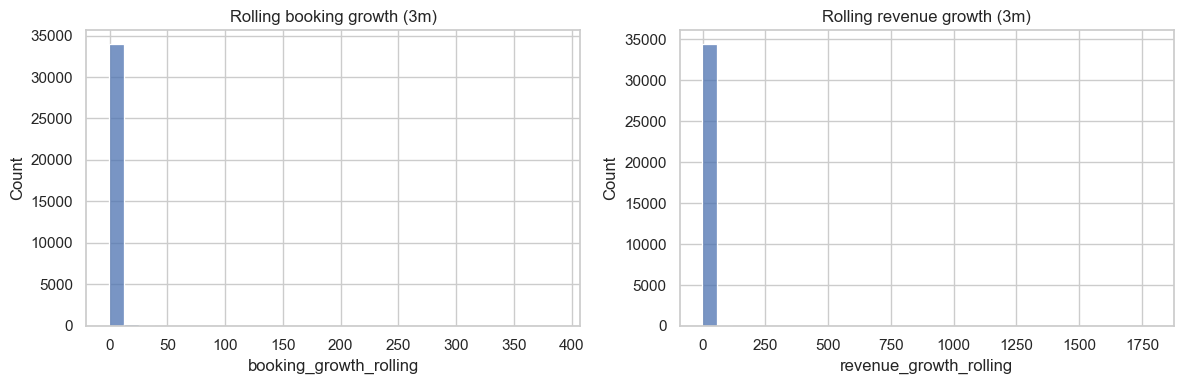

In [19]:
# Growth distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(restaurants_agg["booking_growth_rolling"], bins=30, ax=axes[0])
axes[0].set_title("Rolling booking growth (3m)")

sns.histplot(restaurants_agg["revenue_growth_rolling"], bins=30, ax=axes[1])
axes[1].set_title("Rolling revenue growth (3m)")
plt.tight_layout()

## 5) Standardize into comparable scores

In [20]:
def pct_rank(s: pd.Series) -> pd.Series:
    return s.rank(pct=True, method="average")

restaurants_agg["perf_bookings_rank"] = pct_rank(restaurants_agg["monthly_bookings"])
restaurants_agg["perf_spend_rank"] = pct_rank(restaurants_agg["avg_revenue_per_booking"])
restaurants_agg["performance_score"] = (restaurants_agg["perf_bookings_rank"] + restaurants_agg["perf_spend_rank"]) / 2

restaurants_agg["growth_bookings_rank"] = pct_rank(restaurants_agg["booking_growth_rolling"])
restaurants_agg["growth_revenue_rank"] = pct_rank(restaurants_agg["revenue_growth_rolling"])
restaurants_agg["growth_score"] = (restaurants_agg["growth_bookings_rank"] + restaurants_agg["growth_revenue_rank"]) / 2

restaurants_agg[["performance_score","growth_score"]].describe().T

,count,mean,std,min,25%,50%,75%,max
performance_score,34490.0,0.500014,0.209573,0.037728,0.351569,0.508861,0.659046,0.995013
growth_score,34490.0,0.500014,0.278418,0.000029,0.326095,0.482517,0.744024,1.000000


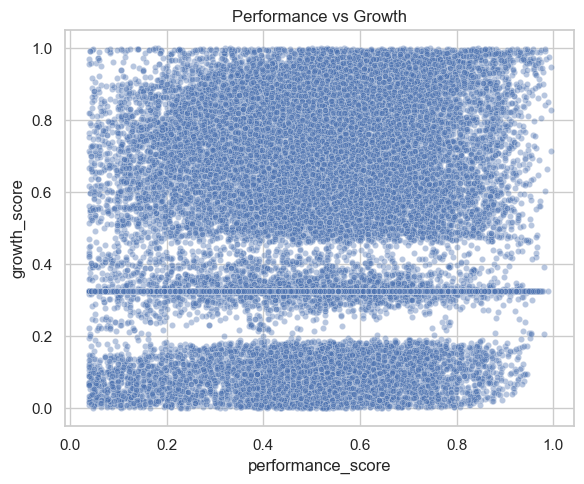

In [21]:
# Performance vs Growth scatter
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=restaurants_agg,
    x="performance_score",
    y="growth_score",
    alpha=0.4,
    s=20
)
plt.title("Performance vs Growth")
plt.tight_layout()

## 6) Composite momentum + segmentation

In [22]:
ALPHA = 0.5
restaurants_agg["momentum_score"] = ALPHA * restaurants_agg["performance_score"] + (1 - ALPHA) * restaurants_agg["growth_score"]

perf_cut = restaurants_agg["performance_score"].median()
grow_cut = restaurants_agg["growth_score"].median()

restaurants_agg["momentum_segment"] = np.select(
    [
        (restaurants_agg["performance_score"] >= perf_cut) & (restaurants_agg["growth_score"] >= grow_cut),
        (restaurants_agg["performance_score"] <  perf_cut) & (restaurants_agg["growth_score"] >= grow_cut),
        (restaurants_agg["performance_score"] >= perf_cut) & (restaurants_agg["growth_score"] <  grow_cut),
        (restaurants_agg["performance_score"] <  perf_cut) & (restaurants_agg["growth_score"] <  grow_cut),
    ],
    [
        "Rising Stars",
        "Emerging Opportunities",
        "Established Players",
        "Needs Attention",
    ],
    default="Unclassified"
)

restaurants_agg[["momentum_score","momentum_segment"]].head()

,momentum_score,momentum_segment
0,0.523347,Established Players
1,0.457002,Established Players
2,0.506603,Established Players
3,0.725660,Rising Stars
4,0.351761,Established Players


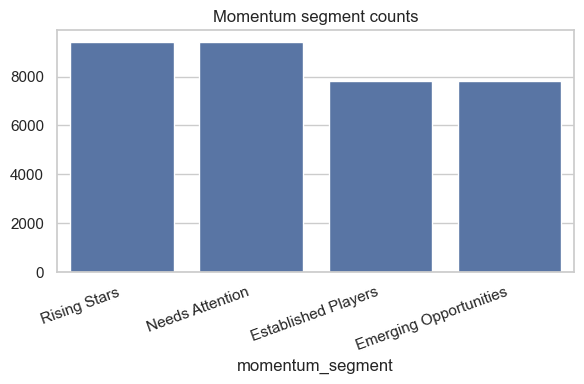

In [23]:
# Segment counts
plt.figure(figsize=(6, 4))
segment_counts = restaurants_agg["momentum_segment"].value_counts()
sns.barplot(x=segment_counts.index, y=segment_counts.values)
plt.title("Momentum segment counts")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

## 7) Latest-month prioritised list

In [24]:
latest_month = restaurants_agg["year_month"].max()
priority_latest = (
    restaurants_agg[restaurants_agg["year_month"] == latest_month]
    .sort_values("momentum_score", ascending=False)
    .reset_index(drop=True)
)

print("Latest month:", latest_month.date())
print(priority_latest["momentum_segment"].value_counts(dropna=False))
priority_latest.head(10)

Latest month: 2025-12-01
momentum_segment
Rising Stars              817
Emerging Opportunities    615
Needs Attention           238
Established Players       125
Name: count, dtype: int64


,restaurant_id,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days,booking_growth_pct,revenue_growth_pct,booking_growth_rolling,revenue_growth_rolling,perf_bookings_rank,perf_spend_rank,performance_score,growth_bookings_rank,growth_revenue_rank,growth_score,momentum_score,momentum_segment
0,5556,2025-12-01,363.0,34026.000000,93.735537,3.231405,31,1.312102,1.551746,26.020701,41.056389,0.962583,0.716092,0.839337,0.991099,0.994317,0.992708,0.916023,Rising Stars
1,6273,2025-12-01,168.0,75937.140000,458.498413,3.625000,23,0.063291,0.135436,1.690265,1.620490,0.929632,0.968629,0.949130,0.893679,0.865033,0.879356,0.914243,Rising Stars
2,4636,2025-12-01,131.0,26618.929749,203.197937,3.206107,26,2.358974,2.378960,2.786325,3.989189,0.915787,0.853175,0.884481,0.938069,0.947318,0.942694,0.913587,Rising Stars
3,6118,2025-12-01,23.0,10521.600000,457.460870,7.652174,13,10.500000,41.980392,4.944444,15.486017,0.729226,0.968397,0.848811,0.964135,0.986634,0.975384,0.912098,Rising Stars
4,4781,2025-12-01,66.0,17848.320000,270.429091,2.969697,19,0.500000,0.696370,3.611111,2.461311,0.866918,0.908495,0.887707,0.951595,0.910844,0.931219,0.909463,Rising Stars
5,4911,2025-12-01,35.0,37420.950772,781.331133,2.485714,14,0.842105,1.923841,2.864035,2.237054,0.793375,0.995013,0.894194,0.939925,0.901508,0.920716,0.907455,Rising Stars
6,4670,2025-12-01,30.0,16983.000000,566.100000,13.700000,12,-0.642857,-0.084425,2.530159,3.123845,0.771021,0.980023,0.875522,0.931777,0.930734,0.931255,0.903389,Rising Stars
7,5215,2025-12-01,324.0,18990.461511,58.612536,2.425926,29,0.280632,0.349900,9.069975,9.472021,0.958858,0.677936,0.818397,0.979008,0.977994,0.978501,0.898449,Rising Stars
8,6206,2025-12-01,281.0,10110.211470,35.979400,3.722420,29,3.683333,6.053260,20.727778,11.855001,0.953798,0.659206,0.806502,0.989446,0.982865,0.986155,0.896329,Rising Stars
9,5008,2025-12-01,141.0,18745.200000,132.944681,2.929078,19,3.548387,3.310430,3.141129,3.902492,0.920281,0.768629,0.844455,0.945259,0.945955,0.945607,0.895031,Rising Stars


In [ ]:
# Save latest-month list
output_path = BASE_DIR / "priority_latest_momentum_labels.parquet"
priority_latest.to_parquet(output_path, index=False)
print("Saved latest-month momentum labels to:", output_path)